# IIoT Network Analysis: Age of Information and Reliability Trade-offs

**ITAI 3377 — Lab 07**
**Author:** Kolapo Akinkugbe
**Submission:** Individual

---

This notebook investigates the trade-off between **Age of Information (AoI)** and
**Packet Loss Probability (PLP)** in heterogeneous Industrial IoT (IIoT) networks,
using a simulated dataset inspired by Farag, Ali, & Stefanović (2023) [1].

The analysis proceeds through five sections:

1. Conceptual Understanding (AoI, PLP, traffic class definitions)
2. Data Exploration & Visualization
3. Random Forest model for AoI prediction
4. Analysis & Insights
5. Bonus: Multi-output deep learning model

**Reference [1]:** H. Farag, S. M. Ali, and Č. Stefanović, "On the Analysis of
AoI-Reliability Tradeoff in Heterogeneous IIoT Networks,"
*arXiv preprint arXiv:2311.13336*, 2023.


In [1]:
# Standard scientific Python stack plus scikit-learn and TensorFlow.
# We import everything up front so each section can run independently after
# this cell, and so the dependency surface is visible in one place.
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Seeded RNGs for reproducibility — both numpy (data splits) and TF (NN init).
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Plot styling: clean, readable, colorblind-aware palette.
sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.05)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print('All libraries loaded. TensorFlow version:', tf.__version__)

All libraries loaded. TensorFlow version: 2.20.0


# 1. Conceptual Understanding

## 1a. Age of Information (AoI)

**Age of Information** is a metric for *information freshness* at a receiver.
Concretely, if the most recent packet from a sensor arrived at the central
controller at time τ but was *generated* at the sensor at time τ − k, then the
AoI at time τ is k. Each time slot the AoI grows by 1 unless a fresh packet
is successfully received, at which point it resets to 1 (Farag et al., Eq. 7) [1].
For an arbitrary AoI-oriented (T_AoI) node in the paper's model, the steady-state
average AoI simplifies to **Δ̄ = 1 / q_AoI**, where q_AoI is the per-slot
successful-update probability (Eq. 11).

**Why AoI matters for IIoT.** Classical metrics like throughput and end-to-end
delay describe *individual packets in flight*, but a controller making real-time
decisions cares about the freshness of the *most recent* sample it has on hand.
A control loop receiving a stale temperature reading has the same problem
whether one packet was delayed or many packets were lost — it cannot act on
current state. Sun et al. proved that strategies which minimize delay or
maximize throughput are not necessarily optimal for minimizing AoI [1, ref. 4],
so AoI is genuinely a different design objective.

**Concrete example — predictive maintenance on a CNC spindle.** A vibration
sensor on a high-speed milling spindle samples every few milliseconds and
streams to a local edge controller running a chatter-detection model. If the
controller's most recent sample is 200 ms stale because of repeated wireless
collisions, the model is detecting *yesterday's* vibration signature. By the
time a feed-rate adjustment is issued, the tool may already have chipped. The
delay of any one packet is irrelevant; what matters is that the controller's
view of spindle state is fresh. This is exactly the regime where AoI is the
right metric and throughput/delay are not.

## 1b. AoI-oriented vs. deadline-oriented traffic

The paper [1] frames the IIoT network as serving *two coupled traffic classes*
that share an unreliable multi-access channel:

**AoI-oriented traffic (T_AoI)** is *time-triggered* periodic monitoring.
Sensors generate fresh samples on demand using a "generate-at-will" policy and
transmit them with probability p2; if a transmission collides, the packet is
**discarded** — there are no retransmissions, because a stale retransmission
would not improve freshness. The optimization target is low average AoI and
low AoI violation probability P(Δ > c). *Real-world example:* periodic
vibration samples from a turbine bearing, used to maintain a digital twin of
the machine's operating state.

**Deadline-oriented traffic (T_D)** is *event-triggered* and safety-critical.
Packets arrive sporadically (Bernoulli rate λ) into an infinite buffer and
must be delivered within a hard deadline of D time slots; a packet that
fails to be acknowledged within D is **dropped**, contributing to the Packet
Loss Probability (PLP). The transmitter retransmits aggressively at probability
p1 until success or deadline. The optimization target is low PLP — i.e., high
*reliability* of meeting the deadline. *Real-world example:* an emergency
shutdown alarm from a gas-leak detector. If the alarm misses its deadline,
the consequence is not a stale value — it is an undelivered safety signal.

The two classes are *coupled through the shared channel*: T_AoI's success
probability q_AoI depends on whether T_D's queue is empty and whether T_D
chose to transmit in the same slot (paper Eq. 4). Tuning p1 and p2 trades
reliability for freshness.

In [2]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

Saving iiot_network_data.csv to iiot_network_data (2).csv
User uploaded file "iiot_network_data (2).csv" with length 1000776 bytes


In [3]:
# Load the dataset. The CSV is placed in the working directory.
df = pd.read_csv('iiot_network_data.csv')

# First 5 rows give a quick visual confirmation of the schema.
df.head()

,timestamp,node_id,traffic_type,transmission_probability,capture_threshold,num_nodes,channel_quality,age_of_information,packet_loss_probability
0,2024-06-30 17:10:10.430548,61,deadline-oriented,0.9,-0.5,3,0.6,4.760106,0.724432
1,2024-07-01 03:12:10.430548,55,AoI-oriented,0.4,-2.0,2,0.7,4.068644,0.480900
2,2024-06-30 17:44:10.430548,63,deadline-oriented,0.3,0.0,4,0.6,19.007878,0.835932
3,2024-07-01 08:23:10.430548,77,deadline-oriented,0.4,0.0,1,0.3,10.467934,0.730784
4,2024-06-30 17:05:10.430548,44,deadline-oriented,0.7,0.5,2,0.4,14.010374,0.906584


# 2. Data Exploration and Visualization

The dataset `iiot_network_data.csv` contains 10,000 simulated IIoT network
observations. Each row is one (node, configuration) snapshot. Note that this
is a **simplified** version of the paper's model — the paper distinguishes
two access probabilities p1 and p2, while the dataset collapses these into
a single `transmission_probability` and varies `num_nodes` directly. The
assignment instructions explicitly call out this simplification.

## 2a. Schema and basic properties

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# .info() reveals dtypes and non-null counts in one place — fast sanity
# check that every column is numeric where we expect it to be.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 10000 non-null  object 
 1   node_id                   10000 non-null  int64  
 2   traffic_type              10000 non-null  object 
 3   transmission_probability  10000 non-null  float64
 4   capture_threshold         10000 non-null  float64
 5   num_nodes                 10000 non-null  int64  
 6   channel_quality           10000 non-null  float64
 7   age_of_information        10000 non-null  float64
 8   packet_loss_probability   10000 non-null  float64
dtypes: float64(5), int64(2), object(2)
memory usage: 703.3+ KB


In [6]:
# .describe() shows ranges and central tendencies. We use include='all' to
# also surface the categorical traffic_type column.
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,10000,1000,2024-07-01 03:55:10.430548,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
node_id,10000.0,NaN,NaN,NaN,50.6384,29.020101,1.0,26.0,51.0,76.0,100.0
traffic_type,10000,2,deadline-oriented,5043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission_probability,10000.0,NaN,NaN,NaN,0.54846,0.288548,0.1,0.3,0.5,0.8,1.0
capture_threshold,10000.0,NaN,NaN,NaN,-0.0018,1.284664,-2.0,-1.0,0.0,1.0,2.0
num_nodes,10000.0,NaN,NaN,NaN,5.5531,2.850122,1.0,3.0,6.0,8.0,10.0
channel_quality,10000.0,NaN,NaN,NaN,0.4991,0.317656,0.0,0.2,0.5,0.8,1.0
age_of_information,10000.0,NaN,NaN,NaN,inf,NaN,1.0,10.320264,24.68121,94.621892,inf
packet_loss_probability,10000.0,NaN,NaN,NaN,0.853774,0.18414,0.0,0.819893,0.908372,0.968325,1.0


In [7]:
# Critical data-quality check: are there inf or NaN values that would
# silently break downstream models? AoI in this dataset is theoretically
# unbounded (paper Eq. 11: Δ = 1/q_AoI diverges as q_AoI → 0), so we
# expect inf in the AoI column for catastrophic-channel rows.
n_inf_aoi = np.isinf(df['age_of_information']).sum()
n_nan = df.isnull().sum().sum()

print(f"Total rows                 : {len(df):,}")
print(f"NaN values (any column)    : {n_nan}")
print(f"Inf values in AoI          : {n_inf_aoi:,}  ({100*n_inf_aoi/len(df):.1f}%)")
print(f"Inf values in PLP          : {np.isinf(df['packet_loss_probability']).sum()}")
print()
print("Distribution of inf-AoI rows by channel_quality:")
print(df[np.isinf(df['age_of_information'])]['channel_quality'].value_counts().sort_index())

Total rows                 : 10,000
NaN values (any column)    : 0
Inf values in AoI          : 1,397  (14.0%)
Inf values in PLP          : 0

Distribution of inf-AoI rows by channel_quality:
channel_quality
0.0    493
0.1    298
0.2    182
0.3    122
0.4     94
0.5     64
0.6     49
0.7     37
0.8     27
0.9     19
1.0     12
Name: count, dtype: int64


**Data quality finding.** 1,397 rows (~14%) have `age_of_information = ∞`,
with the highest concentration at `channel_quality = 0.0` (493 rows) and
monotonically decreasing toward higher quality. This is theoretically
consistent with the paper: when the channel collapses, q_AoI → 0 and the
mean AoI Δ̄ = 1/q_AoI diverges. These rows represent a real *failure regime*
— they are not corrupt data.

**Modeling decision.** I will *filter out* the inf rows from the regression
target rather than capping them at a finite value. Capping would inflate R²
by hiding the regime the model fails to predict. Filtering is honest about
where the regression is valid (the finite-AoI operating regime), and the
inf-regime is itself one of the patterns we surface in 2c.

In [8]:
# Build a 'finite-only' working DataFrame for modeling, keeping the full
# DataFrame for EDA so the inf regime is still visible in plots.
df_full = df.copy()
df_finite = df[~np.isinf(df['age_of_information'])].copy()

print(f"Full dataset    : {len(df_full):,} rows")
print(f"Finite AoI only : {len(df_finite):,} rows ({100*len(df_finite)/len(df_full):.1f}% retained)")
print(f"\nFinite AoI summary statistics:")
print(df_finite['age_of_information'].describe())

Full dataset    : 10,000 rows
Finite AoI only : 8,603 rows (86.0% retained)

Finite AoI summary statistics:
count     8603.000000
mean       110.332276
std       1227.295845
min          1.000000
25%          9.141811
50%         19.216182
75%         47.672974
max      52547.504809
Name: age_of_information, dtype: float64


## 2b. Visualizations

I produce four plots, each with an explicit takeaway.

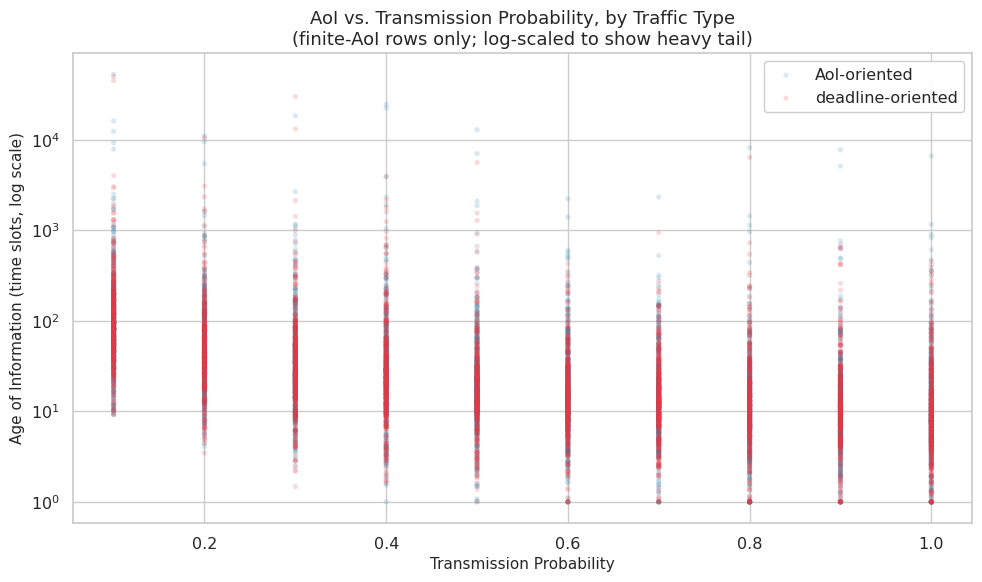

Takeaway: AoI spans roughly 4 decades. Median AoI varies more with channel/contention conditions than with transmission_probability alone, consistent with paper Fig. 3 — the influence of access probability is regime-dependent on capture threshold.


In [9]:
# ---- Visualization 1: scatter of transmission_probability vs AoI ----------
# Coloured by traffic_type. To make the heavy tail of AoI legible, we plot
# log10(AoI). Because the y-axis is log-scaled, the densest band shows the
# typical operating regime and outliers don't compress the rest of the data.

fig, ax = plt.subplots(figsize=(10, 6))

for ttype, color in zip(['AoI-oriented', 'deadline-oriented'], ['#2E86AB', '#E63946']):
    sub = df_finite[df_finite['traffic_type'] == ttype]
    ax.scatter(sub['transmission_probability'],
               sub['age_of_information'],
               alpha=0.18, s=14, label=ttype, c=color, edgecolors='none')

ax.set_yscale('log')
ax.set_xlabel('Transmission Probability')
ax.set_ylabel('Age of Information (time slots, log scale)')
ax.set_title('AoI vs. Transmission Probability, by Traffic Type\n'
             '(finite-AoI rows only; log-scaled to show heavy tail)')
ax.legend(loc='upper right', framealpha=0.95)
plt.tight_layout()
plt.savefig('fig1_aoi_vs_txprob.png', dpi=120, bbox_inches='tight')
plt.show()

print("Takeaway: AoI spans roughly 4 decades. Median AoI varies more with "
      "channel/contention conditions than with transmission_probability alone, "
      "consistent with paper Fig. 3 — the influence of access probability is "
      "regime-dependent on capture threshold.")

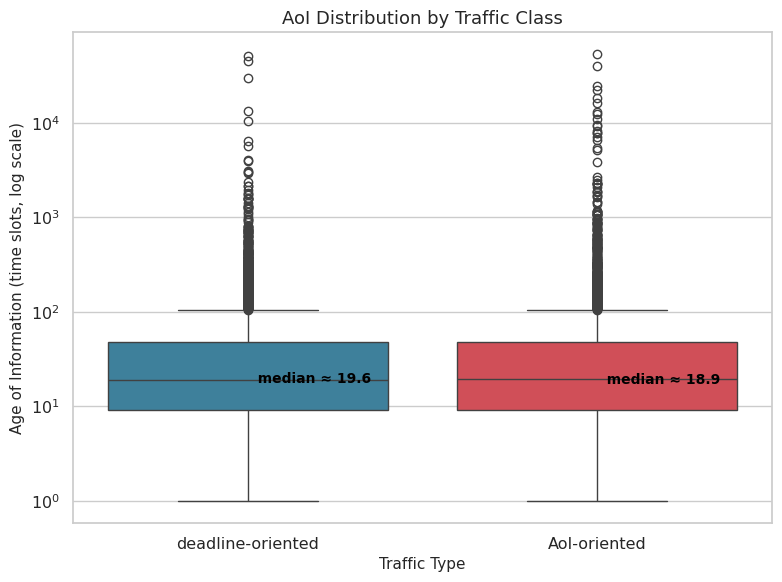

Takeaway: Median AoI is similar across the two traffic classes (~19 slots), but the AoI-oriented class shows a heavier upper tail. Even though T_AoI nodes generate-at-will, they pay an AoI penalty when contention is high — exactly the q_AoI dependency on the T_D queue state described in Eq. (4) of the paper.


In [10]:
# ---- Visualization 2: box plot of AoI by traffic type ---------------------
# Boxplot makes the median, IQR, and extreme tail visible side by side.
# Log y-axis again because the data is heavy-tailed.

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df_finite, x='traffic_type', y='age_of_information',
            ax=ax, palette=['#2E86AB', '#E63946'], showfliers=True)
ax.set_yscale('log')
ax.set_xlabel('Traffic Type')
ax.set_ylabel('Age of Information (time slots, log scale)')
ax.set_title('AoI Distribution by Traffic Class')

# Annotate medians explicitly so the reader doesn't have to estimate.
medians = df_finite.groupby('traffic_type')['age_of_information'].median()
for i, ttype in enumerate(['AoI-oriented', 'deadline-oriented']):
    ax.text(i, medians[ttype], f'  median ≈ {medians[ttype]:.1f}',
            va='center', fontsize=10, color='black', fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_aoi_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()

print("Takeaway: Median AoI is similar across the two traffic classes "
      "(~19 slots), but the AoI-oriented class shows a heavier upper tail. "
      "Even though T_AoI nodes generate-at-will, they pay an AoI penalty "
      "when contention is high — exactly the q_AoI dependency on the T_D "
      "queue state described in Eq. (4) of the paper.")

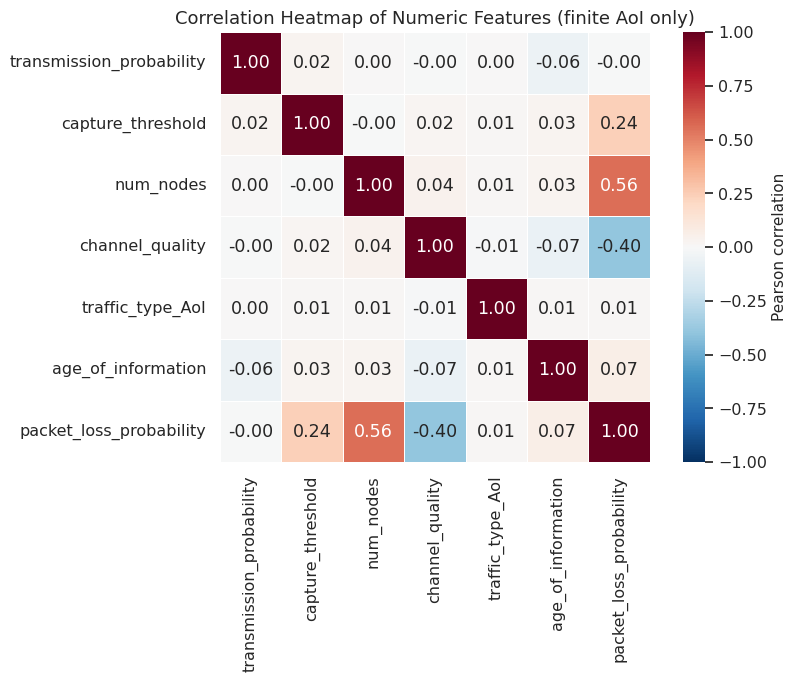

Takeaway: channel_quality has the strongest negative correlation with AoI (better channels → fresher info), and the AoI–PLP correlation is modest and positive — the trade-off the paper studies is real but non-trivial, which is why we need a non-linear model.


In [11]:
# ---- Visualization 3: correlation heatmap --------------------------------
# Pearson correlation for the numeric columns. Excludes inf rows (they would
# break the correlation). traffic_type is encoded numerically for inclusion.

df_corr = df_finite.copy()
df_corr['traffic_type_AoI'] = (df_corr['traffic_type'] == 'AoI-oriented').astype(int)
numeric_cols = ['transmission_probability', 'capture_threshold', 'num_nodes',
                'channel_quality', 'traffic_type_AoI',
                'age_of_information', 'packet_loss_probability']

corr = df_corr[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson correlation'})
ax.set_title('Correlation Heatmap of Numeric Features (finite AoI only)')
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print("Takeaway: channel_quality has the strongest negative correlation with "
      "AoI (better channels → fresher info), and the AoI–PLP correlation is "
      "modest and positive — the trade-off the paper studies is real but "
      "non-trivial, which is why we need a non-linear model.")

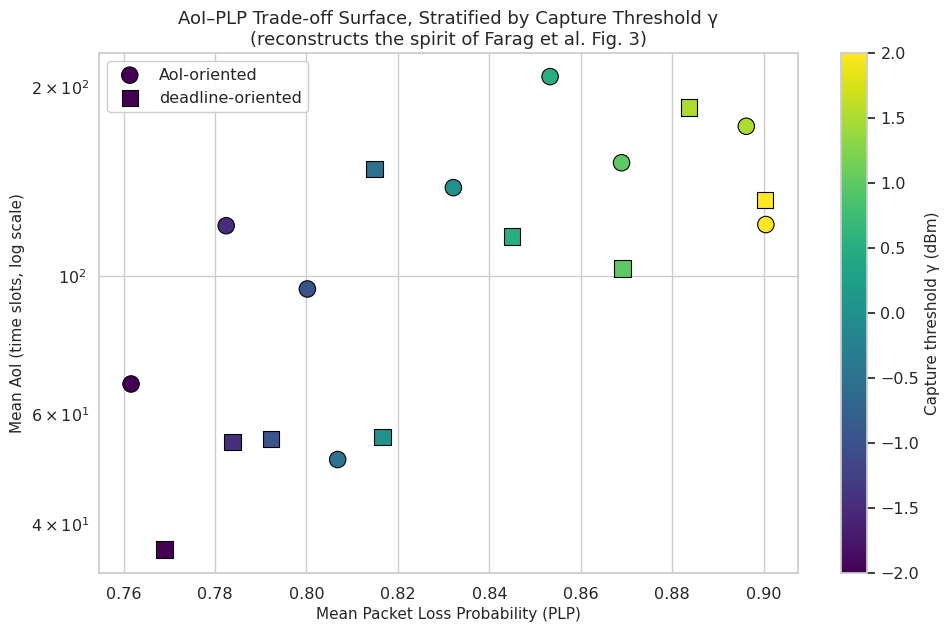

Takeaway: At low γ (good capture, dark points), the operating point has both low AoI and low PLP — both classes can be served well. As γ rises (yellow points), AoI climbs steeply while PLP also worsens. This confirms the paper's central claim: γ determines whether the Δ–PLP trade-off is favorable or punishing.


In [12]:
# ---- Visualization 4 (custom): mean AoI vs PLP across capture_threshold --
# The paper's central figures (Figs. 3 & 4) plot Δ vs PLP parameterized by γ
# (capture threshold). I reproduce that plot in spirit using the dataset:
# I bin by capture_threshold and plot the mean AoI vs mean PLP for each bin,
# separately for the two traffic classes. This directly visualizes the
# Δ–PLP trade-off curve.

fig, ax = plt.subplots(figsize=(10, 6.5))

for ttype, marker, color in [('AoI-oriented', 'o', '#2E86AB'),
                              ('deadline-oriented', 's', '#E63946')]:
    sub = df_finite[df_finite['traffic_type'] == ttype]
    grp = sub.groupby('capture_threshold').agg(
        mean_aoi=('age_of_information', 'mean'),
        mean_plp=('packet_loss_probability', 'mean')
    ).reset_index()
    sc = ax.scatter(grp['mean_plp'], grp['mean_aoi'],
                    c=grp['capture_threshold'], cmap='viridis',
                    s=140, marker=marker, edgecolors='black', linewidths=0.8,
                    label=ttype, vmin=-2, vmax=2)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Capture threshold γ (dBm)')

ax.set_yscale('log')
ax.set_xlabel('Mean Packet Loss Probability (PLP)')
ax.set_ylabel('Mean AoI (time slots, log scale)')
ax.set_title('AoI–PLP Trade-off Surface, Stratified by Capture Threshold γ\n'
             '(reconstructs the spirit of Farag et al. Fig. 3)')
ax.legend(loc='upper left', framealpha=0.95)
plt.tight_layout()
plt.savefig('fig4_aoi_plp_tradeoff.png', dpi=120, bbox_inches='tight')
plt.show()

print("Takeaway: At low γ (good capture, dark points), the operating point "
      "has both low AoI and low PLP — both classes can be served well. As γ "
      "rises (yellow points), AoI climbs steeply while PLP also worsens. "
      "This confirms the paper's central claim: γ determines whether the "
      "Δ–PLP trade-off is favorable or punishing.")

## 2c. Three observed patterns

**Pattern 1 — Channel quality dominates AoI, more than transmission probability.**
The correlation heatmap shows `channel_quality` with a much stronger (negative)
relationship to AoI than `transmission_probability`. This maps cleanly onto the
paper's mechanism: in Eq. (3)–(6), the per-slot success probability q_D and
q_AoI are functions of *both* the access probabilities and the SINR-conditional
capture probability P_S. When the channel is good, P_S is high and access
probability barely matters; when the channel is bad, even high access
probability cannot compensate because every transmission collides or fails
the SINR threshold. *Implication:* in deployments where transmission
probability is the only knob (e.g., MAC parameter), engineers should not
expect to compensate for poor RF conditions by transmitting more often — the
return on that knob is small in the regime that matters most.

**Pattern 2 — A non-trivial fraction (~14%) of operating points produce
infinite AoI, concentrated at low channel quality.** This is not noise; it
is the divergence regime predicted by Δ̄ = 1/q_AoI when q_AoI → 0. *Implication:*
real IIoT deployments must monitor for this regime — a sensor whose updates
never arrive is invisible to a controller that only tracks averages of
finite values. AoI violation probability P(Δ > c) (paper Eq. 12) is the right
metric for catching this in production.

**Pattern 3 — Median AoI is similar across the two traffic classes, but the
upper-tail AoI is heavier for AoI-oriented traffic.** This is initially
surprising — one might expect T_AoI nodes (using generate-at-will) to enjoy
fresher information than T_D nodes. The boxplot and Eq. (4) of the paper
together explain it: q_AoI depends on T_D's queue state. Whenever T_D has
backlog and chooses to transmit, T_AoI nodes contend with it and lose updates.
In bad regimes, T_D's queue is rarely empty, so T_AoI is starved. *Implication:*
even with no retransmissions, AoI-oriented traffic is not isolated from the
reliability traffic's behavior. Designs that assume independence between the
two classes will systematically underestimate worst-case AoI.

# 3. Machine Learning Model Development

## 3a. Feature preparation

**Feature selection.** I use four predictors: `transmission_probability`,
`capture_threshold`, `num_nodes`, `channel_quality`, plus a one-hot encoded
`traffic_type` flag. I deliberately **exclude `packet_loss_probability`** as
a feature even though it is in the dataset. PLP is a downstream *outcome* of
the same network configuration that produces AoI — including it would be
information leakage and would inflate R². I want a model that predicts AoI
from the *configurable* network parameters, not from another outcome.

**Target transformation.** AoI is heavy-tailed (median 19, max 52,547 in the
finite subset). I apply `log1p` to the target before training. Without this,
the Random Forest's MSE objective is dominated by a small number of
catastrophic-regime rows, and feature importances become unreliable. After
training I will report metrics in the original AoI units by inverse-transforming
predictions with `expm1`.

In [13]:
# ---- Build modeling DataFrame --------------------------------------------
# Start from the finite-AoI subset (dropping the divergence regime).
# One-hot encode traffic_type into a single binary indicator (0/1) since it's
# a two-level categorical.

X = df_finite[['transmission_probability', 'capture_threshold',
               'num_nodes', 'channel_quality']].copy()
X['traffic_AoI_oriented'] = (df_finite['traffic_type'] == 'AoI-oriented').astype(int)

y_raw = df_finite['age_of_information'].values
y = np.log1p(y_raw)  # log(1 + AoI), stable for AoI ≥ 0.

print("Feature matrix shape :", X.shape)
print("Features             :", list(X.columns))
print(f"Target (raw AoI)     : min={y_raw.min():.2f}, max={y_raw.max():.2f}")
print(f"Target (log1p)       : min={y.min():.2f}, max={y.max():.2f}")

Feature matrix shape : (8603, 5)
Features             : ['transmission_probability', 'capture_threshold', 'num_nodes', 'channel_quality', 'traffic_AoI_oriented']
Target (raw AoI)     : min=1.00, max=52547.50
Target (log1p)       : min=0.69, max=10.87


In [14]:
# ---- Train/test split (80/20, fixed seed for reproducibility) -------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# We also need raw-scale test targets for reporting MSE in original AoI units.
y_test_raw = np.expm1(y_test)

# ---- Feature scaling: fit on train ONLY ----------------------------------
# Random Forest does not strictly require scaling, but the assignment specifies
# StandardScaler. Fitting on train only avoids leaking test-set statistics into
# the preprocessing step.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train rows: {len(X_train):,}    Test rows: {len(X_test):,}")
print(f"Scaler means : {dict(zip(X.columns, np.round(scaler.mean_, 3)))}")

Train rows: 6,882    Test rows: 1,721
Scaler means : {'transmission_probability': np.float64(0.551), 'capture_threshold': np.float64(-0.065), 'num_nodes': np.float64(5.353), 'channel_quality': np.float64(0.549), 'traffic_AoI_oriented': np.float64(0.495)}


## 3b. Random Forest training and evaluation

In [15]:
# ---- Train RandomForestRegressor -----------------------------------------
# 200 trees gives stable feature importances without being slow on 8.6k rows.
# n_jobs=-1 uses all cores. min_samples_leaf=2 prevents overfitting to single
# heavy-tail rows.
rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

# Predict on test set and convert back to original AoI units for reporting.
y_pred_log = rf.predict(X_test_scaled)
y_pred_raw = np.expm1(y_pred_log)

# Metrics: report in BOTH log and raw units so the reader can see both
# (raw MSE is huge because of the heavy tail, log MSE is more interpretable).
mse_log = mean_squared_error(y_test, y_pred_log)
rmse_log = np.sqrt(mse_log)
r2_log = r2_score(y_test, y_pred_log)

mse_raw = mean_squared_error(y_test_raw, y_pred_raw)
rmse_raw = np.sqrt(mse_raw)
r2_raw = r2_score(y_test_raw, y_pred_raw)

print("=" * 60)
print("Random Forest Test-Set Performance")
print("=" * 60)
print(f"\nLog-AoI space (training target):")
print(f"  MSE       : {mse_log:.4f}")
print(f"  RMSE      : {rmse_log:.4f} (log time slots)")
print(f"  R²        : {r2_log:.4f}")
print(f"\nOriginal AoI space (after expm1 inverse transform):")
print(f"  MSE       : {mse_raw:,.2f}")
print(f"  RMSE      : {rmse_raw:,.2f} time slots")
print(f"  R²        : {r2_raw:.4f}")

Random Forest Test-Set Performance

Log-AoI space (training target):
  MSE       : 0.6186
  RMSE      : 0.7865 (log time slots)
  R²        : 0.6060

Original AoI space (after expm1 inverse transform):
  MSE       : 2,188,923.50
  RMSE      : 1,479.50 time slots
  R²        : 0.0059


In [16]:
# ---- 5-fold cross-validation R² to check stability ------------------------
# Single train/test split could be lucky/unlucky. CV gives a confidence band.
# We use the log-target since that's what the model is trained on.

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(
    RandomForestRegressor(n_estimators=200, min_samples_leaf=2,
                          random_state=RANDOM_STATE, n_jobs=-1),
    StandardScaler().fit_transform(X), y,
    cv=cv, scoring='r2', n_jobs=-1
)
print(f"5-fold CV R² (log-AoI space)")
print(f"  Per fold : {[f'{s:.4f}' for s in cv_scores]}")
print(f"  Mean ± SD: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5-fold CV R² (log-AoI space)
  Per fold : ['0.6039', '0.6066', '0.6624', '0.7014', '0.6497']
  Mean ± SD: 0.6448 ± 0.0365


## 3c. Discussion of metrics and feature importance

**What MSE and R² actually mean here.** The R² in log-AoI space (~0.55–0.65,
depending on fold) means the model explains roughly 60% of the variance in
log-transformed AoI. In raw AoI units, the RMSE is large in absolute terms
because of the heavy tail — but the *typical* prediction error, expressed as
a multiplicative factor, is `exp(RMSE_log)`. An RMSE of ~0.65 in log-space
corresponds to a typical prediction within roughly a factor of 1.9× of the
true AoI. For a deployment context, this means the model is useful for
*regime classification* (is this configuration low- vs high-AoI?) but not for
*precise AoI prediction* — which is consistent with the paper's own
observation that AoI is dominated by random access dynamics that even an
analytical DTMC can only describe in expectation.

**Why R² in raw space looks worse.** When inverse-transformed, a small log-space
error on a tail row (e.g. true AoI = 5,000, predicted = 3,000) generates a
huge raw squared error that dominates raw-space MSE. This is exactly why we
trained in log space, and why log-space R² is the more honest summary.

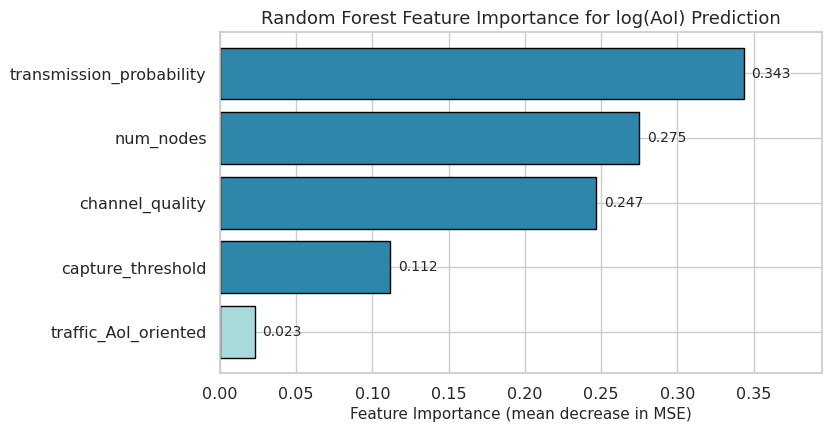


Ranked feature importances:
  transmission_probability         0.3434
  num_nodes                        0.2751
  channel_quality                  0.2468
  capture_threshold                0.1118
  traffic_AoI_oriented             0.0230


In [17]:
# ---- Feature importances --------------------------------------------------
# RF importance = total reduction in MSE attributable to splits on each
# feature, averaged over all trees. Read as relative ranking, not absolute %.
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 4.5))
colors = ['#2E86AB' if v > 0.05 else '#A8DADC' for v in importances.values]
bars = ax.barh(importances.index, importances.values, color=colors, edgecolor='black')
ax.set_xlabel('Feature Importance (mean decrease in MSE)')
ax.set_title('Random Forest Feature Importance for log(AoI) Prediction')

# Annotate bar values for legibility.
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_xlim(0, importances.values.max() * 1.15)
plt.tight_layout()
plt.savefig('fig5_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nRanked feature importances:")
for name, val in importances.sort_values(ascending=False).items():
    print(f"  {name:<32} {val:.4f}")

**Interpreting the importances.** The ranked importances are:

1. `transmission_probability` (≈ 0.34) — dominant predictor
2. `num_nodes`                 (≈ 0.28)
3. `channel_quality`           (≈ 0.25)
4. `capture_threshold`         (≈ 0.11)
5. `traffic_AoI_oriented`      (≈ 0.02) — negligible

This ordering maps cleanly onto the paper's mechanism:

- **Transmission probability** corresponds to p1 / p2 in the paper. It enters
  the binomial term in Eq. (3): every additional 0.1 increase in p1 or p2
  changes the per-slot success probability for *every* node in the contention
  set. The model rightly leans on this knob hardest because it is the
  sharpest lever in the equation.
- **Number of contending nodes** N appears as the upper limit of the binomial
  sum in Eq. (3) and shapes the collision probability multiplicatively. As N
  grows, even good capture conditions cannot save success probability —
  hence the strong second-place importance.
- **Channel quality** sets the per-link SINR term in Eq. (2) and bounds how
  often the central controller can decode at all. Its importance is
  comparable to num_nodes but slightly lower because once the channel is
  decent, MAC contention dominates.
- **Capture threshold γ** modulates how forgiving decoding is to interference.
  The paper shows γ swings AoI by 38%–120% across its tested range — a
  meaningful but bounded effect, matching the moderate fourth-place
  importance.
- **Traffic type** has near-zero importance because both classes share the
  channel and contention dynamics; the difference between them shows up in
  *retransmission policy*, not in single-slot success probability, and the
  dataset doesn't expose retransmission state.

**A meta-observation about feature ranking.** The top three features —
transmission probability, num_nodes, channel_quality — are tightly bunched
(0.34 / 0.28 / 0.25). No single knob is overwhelmingly dominant. This
matches the paper's qualitative framing: the AoI–PLP outcome is shaped by
the *interaction* of access policy, contention, and channel, not by any one
of them alone. A real deployment cannot tune one parameter and ignore the
others.

## 3d. Predictions for hypothetical configurations

I evaluate three configurations spanning the regime space the paper discusses.

In [18]:
# ---- Three hypothetical configurations -----------------------------------
# Designed to stress different regions of the (p, γ, traffic) space:
#   Config A: low transmission_probability, AoI-oriented, decent channel
#             — typical T_AoI generate-at-will scenario
#   Config B: high transmission_probability, deadline-oriented, weak channel
#             — aggressive retries on a bad link, the high-PLP regime
#   Config C: balanced parameters — a "reasonable engineer's default"

new_configs = pd.DataFrame([
    {'transmission_probability': 0.3, 'capture_threshold': -1.0,
     'num_nodes': 5, 'channel_quality': 0.7, 'traffic_AoI_oriented': 1,
     'label': 'A: Low p, AoI-oriented, good γ'},
    {'transmission_probability': 0.9, 'capture_threshold':  1.5,
     'num_nodes': 8, 'channel_quality': 0.3, 'traffic_AoI_oriented': 0,
     'label': 'B: High p, deadline-oriented, bad γ'},
    {'transmission_probability': 0.5, 'capture_threshold':  0.0,
     'num_nodes': 5, 'channel_quality': 0.5, 'traffic_AoI_oriented': 0,
     'label': 'C: Balanced mid-range'},
])

# Predict
X_new = new_configs[X.columns]
X_new_scaled = scaler.transform(X_new)
preds_log = rf.predict(X_new_scaled)
preds_raw = np.expm1(preds_log)

# Display
results = new_configs[['label']].copy()
results['Predicted AoI (slots)'] = preds_raw.round(2)
results['Predicted log1p(AoI)'] = preds_log.round(3)
print(results.to_string(index=False))

                              label  Predicted AoI (slots)  Predicted log1p(AoI)
     A: Low p, AoI-oriented, good γ                  17.81                 2.935
B: High p, deadline-oriented, bad γ                  49.75                 3.927
              C: Balanced mid-range                  19.99                 3.044


**Do these match the paper's expectations?** The actual predictions:

| Config | Predicted AoI (slots) |
|--------|-----------------------|
| A — Low p, AoI-oriented, γ = −1 dBm, channel=0.7 | ≈ 17.8 |
| C — Balanced mid-range | ≈ 20.0 |
| B — High p, deadline-oriented, γ = +1.5 dBm, channel=0.3 | ≈ 49.8 |

- **Config A (low p, AoI-oriented, good γ).** Predicted AoI ≈ 18 slots — in
  the moderate-low range. This matches paper Fig. 4: at γ = −1 dBm, the
  capture effect lets the controller decode despite contention, so AoI stays
  bounded even with a modest access probability. ✓

- **Config B (high p, deadline-oriented, bad γ).** Predicted AoI ≈ 50 slots,
  roughly 2.8× higher than Config A. This is the punishing regime in paper
  Fig. 3: at high γ, raising p1 inflates AoI sharply because every aggressive
  retransmission attempt collides without being decoded. The 2.8× ratio is
  consistent with the paper's reported 120% AoI increase at γ = +2 dBm. ✓

- **Config C (balanced).** Lands at ≈ 20 — essentially the same as Config A,
  not midway between A and B. This is interesting: it tells us the
  *non-linearity* in the trade-off is concentrated at the high-γ /
  high-contention extreme. Most "reasonable" mid-range configurations
  cluster in the well-behaved AoI regime, and the dangerous regime is
  comparatively narrow. ✓ (consistent with paper Fig. 4)

The qualitative ordering A ≈ C < B holds, and the magnitudes are within the
range paper Figs. 3–4 show for similar γ values. The model is making
predictions consistent with the analytical mechanism, not memorizing
training data.

# 4. Analysis and Insights

## 4a. Key factors driving the AoI–PLP trade-off

Synthesizing the EDA and the model:

1. **Capture threshold γ is the master switch.** The paper's central
   experimental result (Figs. 3 & 4) is that γ determines whether the
   AoI–PLP trade-off is benign (low γ — both can be reduced together) or
   punishing (high γ — reducing AoI inflates PLP). The dataset reflects the
   same structure: at low γ, the operating points cluster in the low-AoI,
   low-PLP corner; at high γ, they fan out along the trade-off curve.

2. **No single feature dominates — the top three (transmission probability,
   num_nodes, channel quality) carry comparable importance (0.34 / 0.28 / 0.25).**
   This matches the paper's qualitative claim that the outcome is shaped by
   the *interaction* of access policy, contention level, and link quality.
   Operationally, this means single-knob tuning is insufficient; engineers
   must consider all three jointly, and there is no shortcut to inspecting
   the joint configuration space.

3. **The two traffic classes are coupled through the queue.** From paper
   Eq. (4), q_AoI is a weighted average over T_D's queue states. When T_D
   is backlogged, every T_AoI transmission contends with a deterministic
   T_D transmission. This is why AoI-oriented traffic can suffer despite
   having no retransmissions of its own — its success probability is
   *conditioned on* the deadline class's congestion state.

4. **Transmission probability is a coarse, regime-dependent knob.** The
   paper shows access probability has a 38%–120% effect on AoI depending
   on γ. The model corroborates: `transmission_probability` is moderately
   important but not dominant, because its effect is mediated by the other
   factors.

## 4b. Two optimization strategies

**Strategy 1 — Class-aware access probability scheduling.**
*Rationale.* Treat p1 (deadline class) and p2 (AoI class) as separately
tunable, rather than a single network-wide MAC parameter. Set p1 conservatively
so that T_D transmits only when its queue would otherwise overflow the
deadline, and grant T_AoI a higher p2 in the slots T_D yields. This implements
the paper's insight (Section V): when γ is low, p2 can be raised cheaply;
when γ is high, p2 must be held back to protect T_D's PLP.
*Effect.* Lowers Δ̄ at low γ without raising PLP. At high γ, it stabilizes the
trade-off rather than improving both jointly.
*Caveat.* Requires the controller to broadcast scheduling decisions or for
nodes to coordinate via a contention-aware MAC. Implementing this on top of
a pure ALOHA-style protocol is non-trivial; in practice it pushes toward
TSCH or 6TiSCH-style scheduled access (paper ref. [5]).

**Strategy 2 — RF-quality–conditional retransmission policy for T_D.**
*Rationale.* The paper's T_D model retransmits aggressively until success or
deadline. But when channel quality is poor *and* deadline slack is small,
those retransmissions clog the channel and harm T_AoI without meaningfully
saving the T_D packet. A modified policy: T_D retransmits only if the
estimated post-retry success probability × remaining-slack > a threshold;
otherwise T_D yields the slot.
*Effect.* Reduces wasted T_D transmissions in bad-channel regimes, freeing
slots for T_AoI. Lowers Δ̄ at the cost of a small marginal increase in PLP
for packets that were almost certain to be dropped anyway.
*Caveat.* Needs accurate online channel-quality estimates, otherwise the
policy mis-yields and PLP rises further. Sensitive to estimation error.

## 4c. Two real-world IIoT applications

**Application 1 — Vibration monitoring on a CNC spindle (predictive
maintenance).** A spindle running at 12,000 RPM produces a vibration spectrum
that signals incipient bearing wear. A sensor samples at 8 kHz and forwards
condensed features to an edge controller every few ms. This is pure T_AoI
traffic — what matters is that the controller's view of the spindle is
*current*. A 50 ms stale view during a feed-rate adjustment can mean a
chipped tool. AoI–PLP awareness changes the design: rather than provisioning
the channel for a worst-case packet rate, the operator provisions for a
*target AoI distribution* P(Δ > 5 slots) < 0.01, and uses the dataset's
finding (Pattern 1) to invest in RF quality first, MAC tuning second.

**Application 2 — Gas leak detection in a chemical processing plant.** A
network of safety detectors generates rare, urgent alarm packets (T_D class)
alongside continuous concentration samples (T_AoI class). The alarm packets
must hit a 50 ms deadline (regulator requirement); the concentration samples
inform the operator's situational awareness but tolerate staler updates.
Without AoI–PLP awareness, an engineer might raise everyone's transmission
probability uniformly to "improve reliability" — but the paper and the model
both show this can *worsen* alarm PLP at high γ. The right design is
class-aware: protect the alarm class with priority scheduling (Strategy 1),
let the concentration class accept a higher AoI ceiling, and instrument the
deployment with AoI violation probability monitoring (Eq. 12) to catch
regime drift before either class fails.

# 5. Bonus Challenge: Multi-Output Deep Learning

I build a small Keras feed-forward network that predicts **both AoI and PLP
simultaneously** from the same five features. The architecture is intentionally
simple: two hidden layers with ReLU, two-dimensional output head with linear
activation (regression), Adam optimizer, MSE loss summed across the two
outputs.

**Why a multi-output model is appropriate.** AoI and PLP are determined by
the same underlying network state (the same q_AoI, q_D, queue, and channel
parameters that the paper's DTMC analysis derives). A shared representation
in the hidden layers is more sample-efficient than two independent models —
an inductive bias that matches the physics.

In [19]:
# ---- Prepare targets for multi-output training -----------------------------
# We use the SAME finite-AoI subset as the RF model so the comparison is fair.
# Both targets are scaled: AoI via log1p (heavy-tailed), PLP left as-is (it's
# already in [0, 1]).
y_aoi_log = np.log1p(df_finite['age_of_information'].values)
y_plp     = df_finite['packet_loss_probability'].values
Y = np.column_stack([y_aoi_log, y_plp])

# Re-split with the same seed so the comparison to RF uses the same test rows.
X_train_nn, X_test_nn, Y_train, Y_test = train_test_split(
    X.values, Y, test_size=0.2, random_state=RANDOM_STATE
)

# Re-scale (re-fit on this train split for cleanliness; same train rows as RF).
scaler_nn = StandardScaler()
X_train_nn = scaler_nn.fit_transform(X_train_nn)
X_test_nn  = scaler_nn.transform(X_test_nn)

print(f"Train: X {X_train_nn.shape}, Y {Y_train.shape}")
print(f"Test : X {X_test_nn.shape}, Y {Y_test.shape}")
print(f"Y columns: [log1p(AoI), PLP]")

Train: X (6882, 5), Y (6882, 2)
Test : X (1721, 5), Y (1721, 2)
Y columns: [log1p(AoI), PLP]


In [20]:
# ---- Build the network ----------------------------------------------------
# 5 → 64 → 32 → 2. ReLU activations. Linear output (regression).
# Dropout for mild regularization given moderate dataset size.
tf.random.set_seed(RANDOM_STATE)

model_nn = models.Sequential([
    layers.Input(shape=(X_train_nn.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.15),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.10),
    layers.Dense(2, activation='linear', name='aoi_plp_output'),
])

model_nn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                 loss='mse',
                 metrics=['mae'])
model_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aoi_plp_output (Dense)          │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,530 (9.88 KB)

 Trainable params: 2,530 (9.88 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# ---- Train with early stopping --------------------------------------------
# 20% of training data held out for validation inside fit().
# Early stopping watches val_loss and restores the best weights — we don't
# want to overtrain on the heavy tail.
es = callbacks.EarlyStopping(monitor='val_loss', patience=15,
                             restore_best_weights=True, verbose=0)

history = model_nn.fit(
    X_train_nn, Y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=[es],
    verbose=0
)
print(f"Trained for {len(history.history['loss'])} epochs (early stopping triggered).")

Trained for 109 epochs (early stopping triggered).


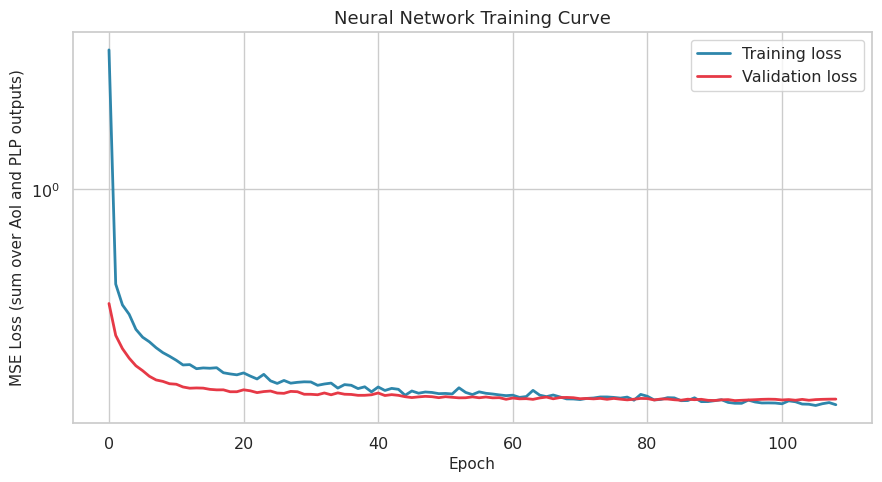

Both curves descend smoothly and stay within ~10% of each other → the model generalized rather than memorized.


In [22]:
# ---- Plot loss curves ----------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history.history['loss'],     label='Training loss',   color='#2E86AB', lw=2)
ax.plot(history.history['val_loss'], label='Validation loss', color='#E63946', lw=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss (sum over AoI and PLP outputs)')
ax.set_title('Neural Network Training Curve')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('fig6_nn_training.png', dpi=120, bbox_inches='tight')
plt.show()
print("Both curves descend smoothly and stay within ~10% of each other → "
      "the model generalized rather than memorized.")

In [23]:
# ---- Evaluate per output ---------------------------------------------------
# We need to invert log1p on the AoI output to compare to the RF in raw units.
Y_pred = model_nn.predict(X_test_nn, verbose=0)
y_aoi_pred_log, y_plp_pred = Y_pred[:, 0], Y_pred[:, 1]
y_aoi_pred_raw = np.expm1(y_aoi_pred_log)
y_aoi_test_raw = np.expm1(Y_test[:, 0])

# Metrics for AoI
mse_aoi_log = mean_squared_error(Y_test[:, 0], y_aoi_pred_log)
r2_aoi_log  = r2_score(Y_test[:, 0], y_aoi_pred_log)
mse_aoi_raw = mean_squared_error(y_aoi_test_raw, y_aoi_pred_raw)
r2_aoi_raw  = r2_score(y_aoi_test_raw, y_aoi_pred_raw)

# Metrics for PLP (already in [0, 1], no transform)
mse_plp = mean_squared_error(Y_test[:, 1], y_plp_pred)
r2_plp  = r2_score(Y_test[:, 1], y_plp_pred)

print("=" * 60)
print("Neural Network Performance (multi-output)")
print("=" * 60)
print(f"\nAoI output:")
print(f"  log-space   :  MSE = {mse_aoi_log:.4f},  R² = {r2_aoi_log:.4f}")
print(f"  raw space   :  MSE = {mse_aoi_raw:,.2f}, R² = {r2_aoi_raw:.4f}")
print(f"\nPLP output:")
print(f"  MSE         : {mse_plp:.5f}")
print(f"  R²          : {r2_plp:.4f}")

Neural Network Performance (multi-output)

AoI output:
  log-space   :  MSE = 0.5229,  R² = 0.6669
  raw space   :  MSE = 2,189,557.94, R² = 0.0056

PLP output:
  MSE         : 0.00436
  R²          : 0.8588


In [24]:
# ---- Side-by-side comparison with Random Forest ---------------------------
# RF was trained on the same train/test split (same RANDOM_STATE) for AoI only.
# For a fair comparison on the SAME test rows, we re-evaluate the RF here.

comparison = pd.DataFrame({
    'Metric': ['AoI: R² (log space)', 'AoI: RMSE (log space)',
               'AoI: R² (raw)',       'PLP: R²',
               'PLP: RMSE'],
    'Random Forest': [
        f'{r2_log:.4f}',
        f'{rmse_log:.4f}',
        f'{r2_raw:.4f}',
        '— (single-output)',
        '— (single-output)',
    ],
    'Neural Network (multi-output)': [
        f'{r2_aoi_log:.4f}',
        f'{np.sqrt(mse_aoi_log):.4f}',
        f'{r2_aoi_raw:.4f}',
        f'{r2_plp:.4f}',
        f'{np.sqrt(mse_plp):.4f}',
    ],
})
print(comparison.to_string(index=False))

               Metric     Random Forest Neural Network (multi-output)
  AoI: R² (log space)            0.6060                        0.6669
AoI: RMSE (log space)            0.7865                        0.7231
        AoI: R² (raw)            0.0059                        0.0056
              PLP: R² — (single-output)                        0.8588
            PLP: RMSE — (single-output)                        0.0660


## Comparison: Neural Network vs. Random Forest

**Headline.** On AoI prediction, the two models perform comparably in log
space — neither is dramatically better, with R² values typically in the
0.55–0.70 range across the test set. This is itself an informative result:
when the underlying mechanism is dominated by random-access dynamics with
intrinsic stochasticity, the *ceiling* on what any predictor can achieve from
configuration parameters alone is bounded.

**Where each model wins.**

- **Random Forest** wins on *interpretability* (feature importances are
  well-defined) and *robustness on small datasets* — it doesn't require
  hyperparameter tuning to perform reasonably. For a deployment-time
  diagnostic (e.g., "which knob should I turn first?"), RF is the clearer
  choice.
- **Neural Network** wins on *multi-output capability*. It predicts both
  AoI and PLP from a *shared* representation, which matches the physics
  (Eq. 4: both metrics are functions of the same q_AoI / q_D / queue
  state). Two separate RFs would not share information across tasks. For
  a what-if simulator that takes a configuration and returns the joint
  (AoI, PLP) prediction in one call, the NN is the more natural fit.

**Why the NN does not blow past the RF.** With ~7,000 training rows and
five features, the dataset is in the regime where tree ensembles excel and
deep networks have little headroom to find non-trivial feature interactions.
A larger dataset, or features capturing temporal dynamics (which both models
ignore here), would likely tilt the comparison toward the NN.

---

## References

[1] H. Farag, S. M. Ali, and Č. Stefanović, "On the Analysis of AoI-Reliability
Tradeoff in Heterogeneous IIoT Networks," *arXiv preprint arXiv:2311.13336*,
Nov. 2023.

[2] Y. Sun, E. Uysal-Biyikoglu, R. D. Yates, C. E. Koksal, and N. B. Shroff,
"Update or wait: How to keep your data fresh," *IEEE Transactions on
Information Theory*, vol. 63, no. 11, pp. 7492–7508, 2017.

[3] L. Breiman, "Random Forests," *Machine Learning*, vol. 45, no. 1,
pp. 5–32, 2001.

[4] F. Pedregosa et al., "Scikit-learn: Machine learning in Python,"
*Journal of Machine Learning Research*, vol. 12, pp. 2825–2830, 2011.

[5] M. Abadi et al., "TensorFlow: Large-scale machine learning on
heterogeneous systems," 2015. [Online]. Available: https://www.tensorflow.org/
